# System 4: $V(r) = -10e^{-r^2}+15e^{-(r-9.0)^2/1.5^2}$, $s$-wave bound state, semi-narrow $p$-wave resonance.
- Supports an $s$-wave bound state at $E_b=-2.54340$.
- Supports a $p$-wave resonance at $E_r=0.281 -i0.096$
    - $\phi_\text{min}=\text{arg}(E) / 2 \approx 0.164$.
    - $V(r)$ is a Gaussian, so $\phi_\text{max}=\pi/4\approx0.785$
- $\phi_\text{min} \le \phi < \phi_\text{max} = 0.164 \le \phi < 0.785$.
- By $r=5$, $V(r=18)\propto 10^{-15} \approx 0$.

Due to finite volume effects, the good region of $\phi$ might vary from its theoretical value. This is a very narrow resonance. This gives
EC a much larger region to train over and a much smaller gap to extrapolate across for back-rotation.

In [1]:
from src.dvr import DVR
from src.ec import ECSystem

from src.utils.sweep_utils import *
from src.utils.print_plot_utils import *
from src.utils.reference_utils import *
from src.utils.predict_utils import *

import numpy as np
import matplotlib.pyplot as plt

In [2]:
system_num = 4

n_guess = 256
L_guess = 50.0
phi_guess = 0.35
res_guess = 0.277122 - 1j*0.09318  # expected value of resonance
bound_guess = -2.54 + 1j*0.0   # due to finite volume, there will be a small imaginary component from CSM
telem_guess = 0.751217 - 1j*0.1917267483744472
rr_guess = 0.6024 + 1j*0.06062

V_0, R = 10.0, 1.0
r_b, w, V_b = 9.0, 1.5, 15.0
def gauss_barrier(r):
    att_gauss = -V_0 * np.exp(-r**2/R**2)
    extra_barr = V_b * np.exp(-(r-r_b)**2/w**2)
    return att_gauss + extra_barr

In [3]:
sbound_system = DVR(n_guess, L_guess, rotation_angle=0.0, potential=gauss_barrier, l=0)
pres_system = DVR(n_guess, L_guess, rotation_angle=phi_guess, potential=gauss_barrier, l=1)

In [4]:
save_plots = True
plots_folder = get_plots_path() / f"system_{system_num}_complexphi"
plots_folder.mkdir(exist_ok=True, parents=True)

### $E(L)$, $(r_\theta^2)(L)$, $(\psi_\text{res}|r|\psi_\text{bound})$ at fixed $\phi$.

In [5]:
# compute <r^2> as L varies
mesh_width_guess = 0.2
observables = {"energies": obs_energy, "rrs": obs_rr, "telems": obs_telem}

Ls = np.linspace(20.0, 70., 20)
results = linesweep_L(
    phi_guess,
    res_guess,
    Ls,
    mesh_width_guess,
    observables,
    resonance_potential=gauss_barrier,
    resonance_l=1,
    bound_energy=bound_guess,
    bound_potential=gauss_barrier,
    bound_l=0
)
energies = results["energies"]
rrs = results["rrs"]
telems = results["telems"]
ns = results["ns"]
actual_mesh_widths = results["actual_mesh_widths"]

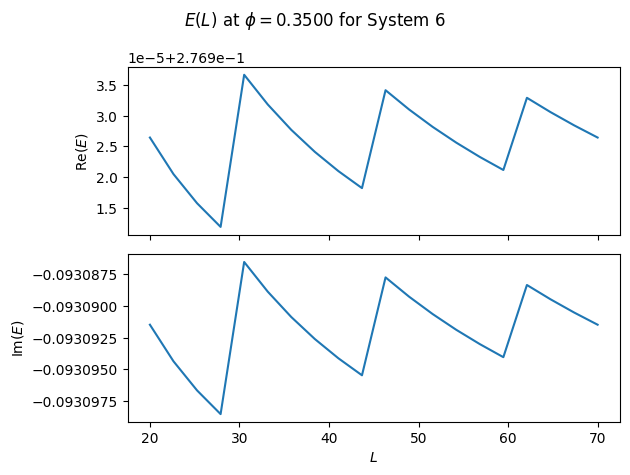

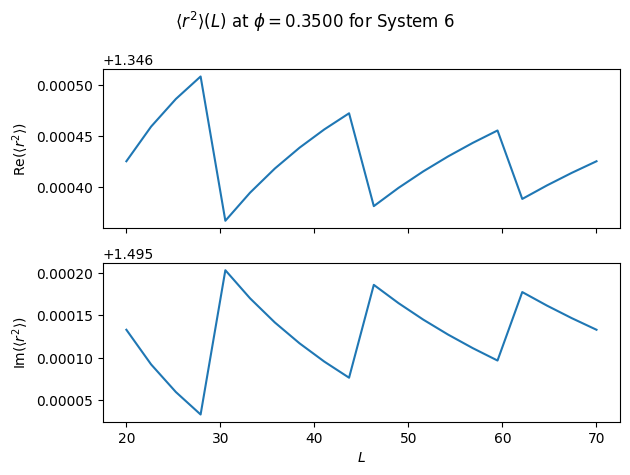

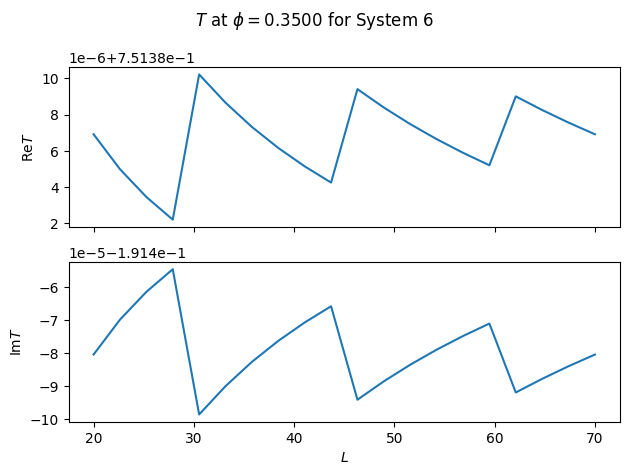

In [6]:
# plot E(L)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(Ls, np.real(energies))
ax2.plot(Ls, np.imag(energies))
ax1.set_ylabel(r"Re$(E)$")
ax2.set_ylabel(r"Im$(E)$")
ax2.set_xlabel(r"$L$")
fig.suptitle(rf"$E(L)$ at $\phi=${phi_guess:.4f} for System 6")
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "E_stability_L")
plt.show()
residual
# plot <r^2>(L)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(Ls, np.real(rrs))
ax2.plot(Ls, np.imag(rrs))
ax1.set_ylabel(r"Re$(\langle r^2\rangle)$")
ax2.set_ylabel(r"Im$(\langle r^2\rangle)$")
ax2.set_xlabel(r"$L$")
fig.suptitle(rf"$\langle r^2\rangle(L)$ at $\phi=${phi_guess:.4f} for System 6")
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "rr_stability_L.png")
plt.show()

# plot <r^2>(L)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(Ls, np.real(telems))
ax2.plot(Ls, np.imag(telems))
ax1.set_ylabel(r"Re$T$")
ax2.set_ylabel(r"Im$T$")
ax2.set_xlabel(r"$L$")
fig.suptitle(rf"$T$ at $\phi=${phi_guess:.4f} for System 6")
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "telem_stability_L.png")
plt.show()

### $E(\phi)$, $(r^2)(\theta)$, $(\psi_\text{res}|r|\psi_\text{bound})$ at fixed $L$ (real $\phi$).

In [7]:
# compute E and <r^2> as phi varies
# the ABC theorem says that this should be const.
phi_scan = 20
phi_lo, phi_hi = 0.3, 0.47 #get_phi_bounds(res_guess)
phis = np.linspace(phi_lo, phi_hi, phi_scan)

results = linesweep_phi(
    pres_system,
    res_guess,
    phis,
    observables,
    sbound_system,
    bound_guess
)
energies, rrs, telems = results["energies"], results["rrs"], results["telems"]   

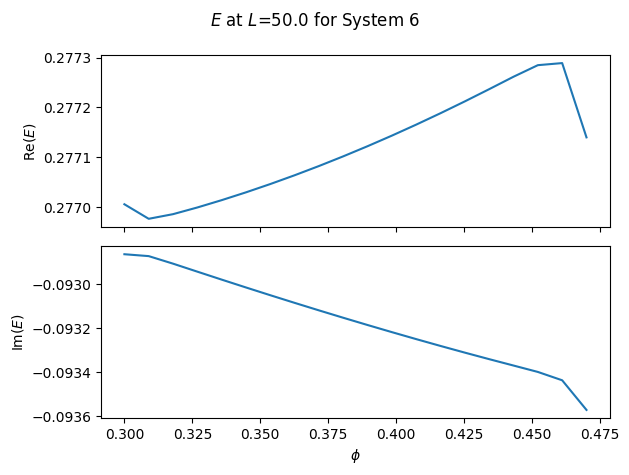

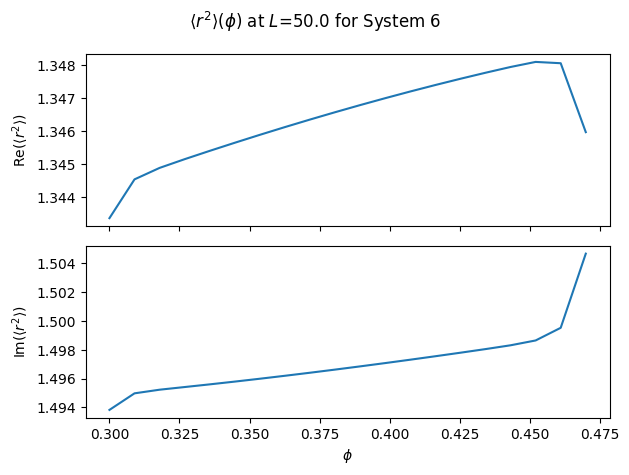

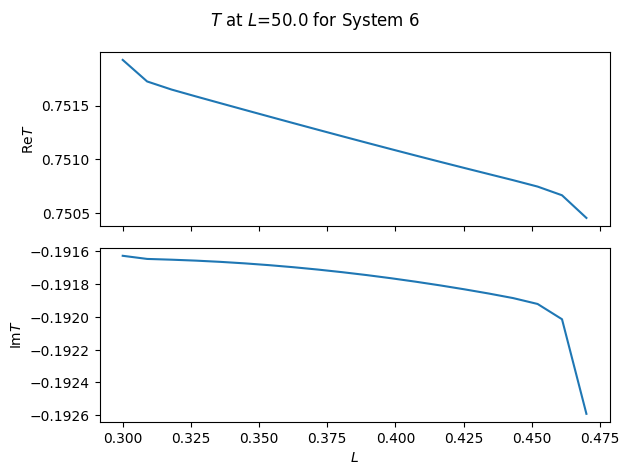

In [8]:
# plot <E>(phi)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(phis, np.real(energies))
ax2.plot(phis, np.imag(energies))
ax1.set_ylabel(r"Re$(E)$")
ax2.set_ylabel(r"Im$(E)$")
ax2.set_xlabel(r"$\phi$")
fig.suptitle(rf"$E$ at $L$={L_guess} for System 6")
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "E_stability_phi.png")
plt.show()

# plot <r^2>(phi)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(phis, np.real(rrs))
ax2.plot(phis, np.imag(rrs))
ax1.set_ylabel(r"Re$(\langle r^2\rangle)$")
ax2.set_ylabel(r"Im$(\langle r^2\rangle)$")
ax2.set_xlabel(r"$\phi$")
fig.suptitle(rf"$\langle r^2\rangle(\phi)$ at $L$={L_guess} for System 6")
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "rr_stability_phi.png")
plt.show()

# plot transition matrix elements
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(phis, np.real(telems))
ax2.plot(phis, np.imag(telems))
ax1.set_ylabel(r"Re$T$")
ax2.set_ylabel(r"Im$T$")
ax2.set_xlabel(r"$L$")
fig.suptitle(rf"$T$ at $L$={L_guess} for System 6")
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "telem_stability_phi.png")
plt.show()

### Extend $\phi$ to the complex plane and analyze plateau regions using DVR

In [9]:
# phi region that looks good is phi = (0.3, 0.55)
phis_real = np.linspace(0.31, 0.47, 5)
phis_imag = np.linspace(-.15, .4, 5)

results = gridsweep_phi(
    pres_system,
    res_guess,
    phis_real,
    phis_imag,
    observables,
    sbound_system,
    bound_guess
)
energies = results["energies"]
rrs = results["rrs"]
telems = results["telems"]
benergies = results["bound_energies"]

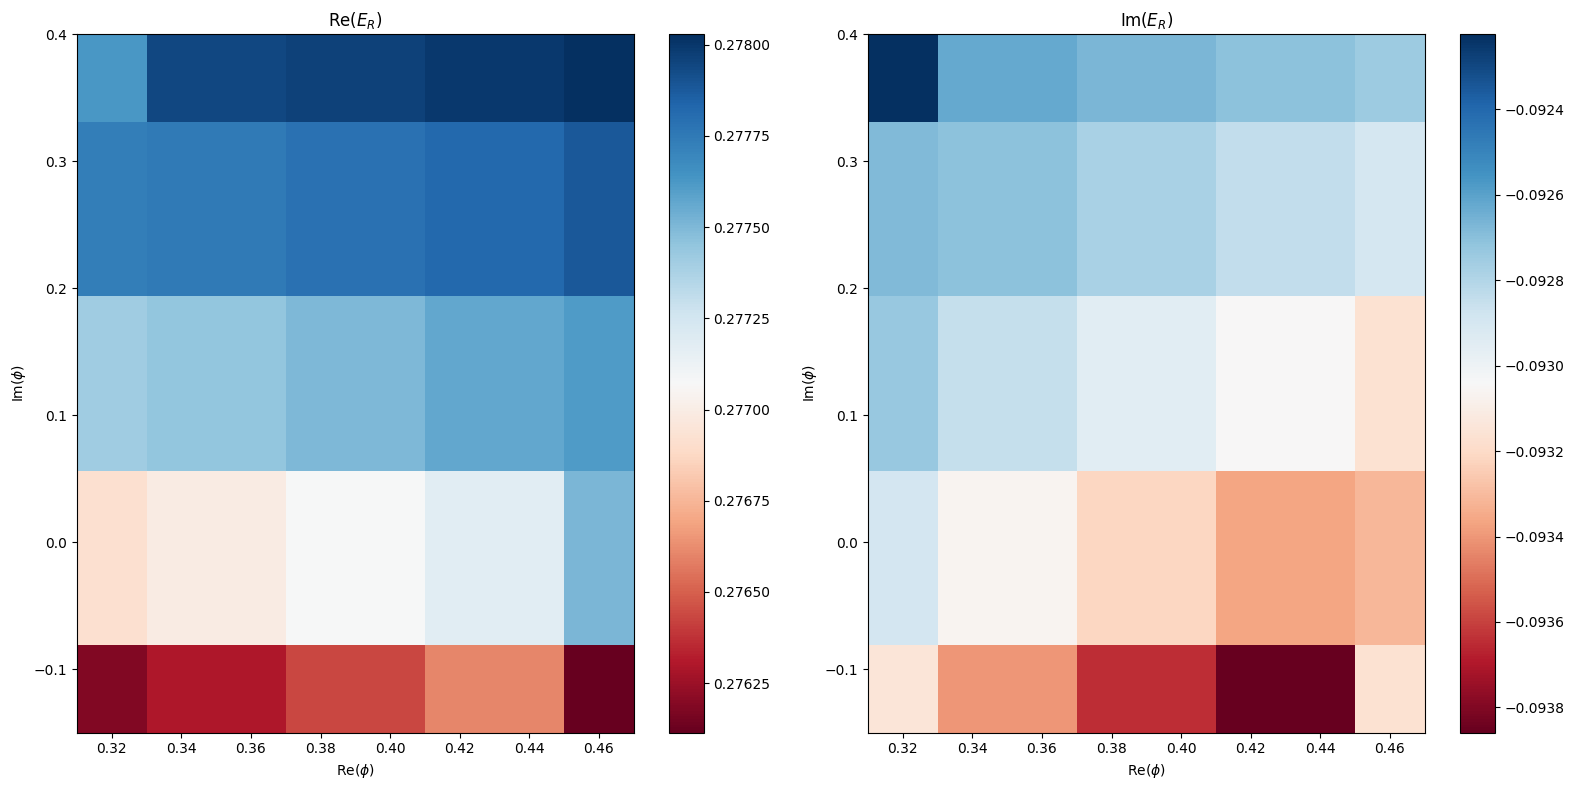

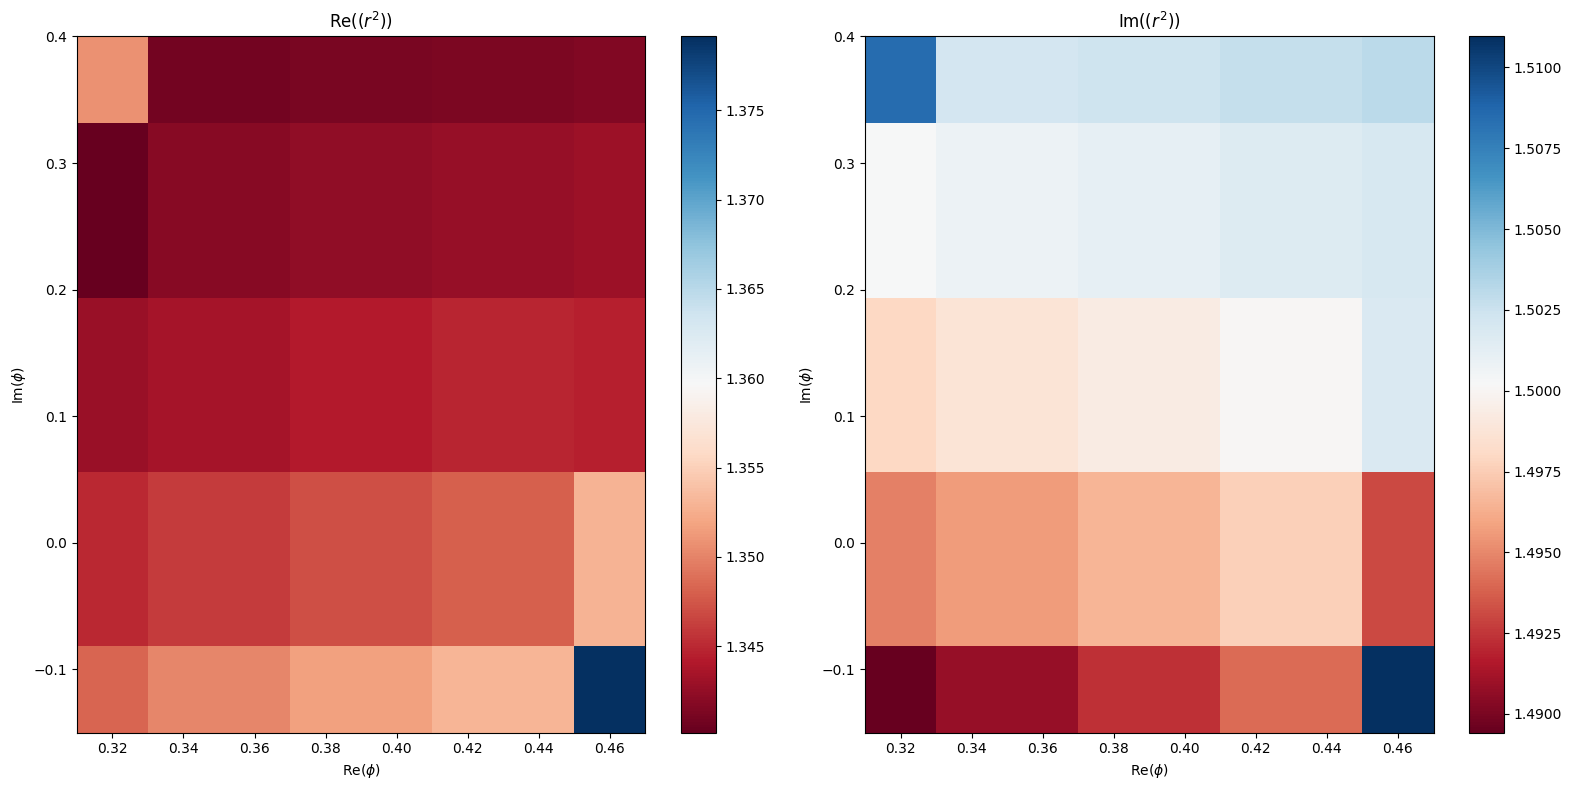

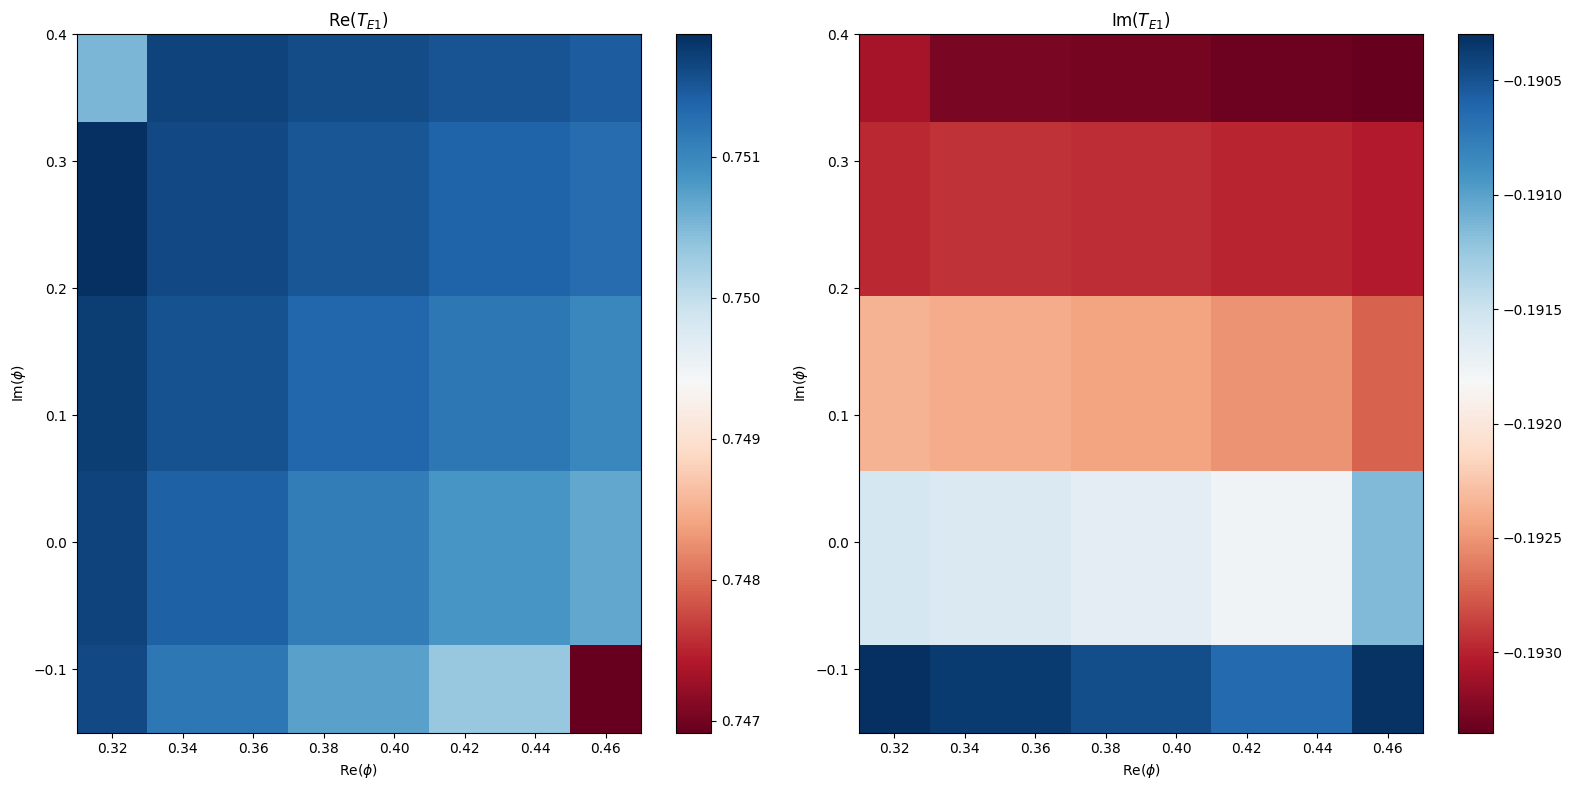

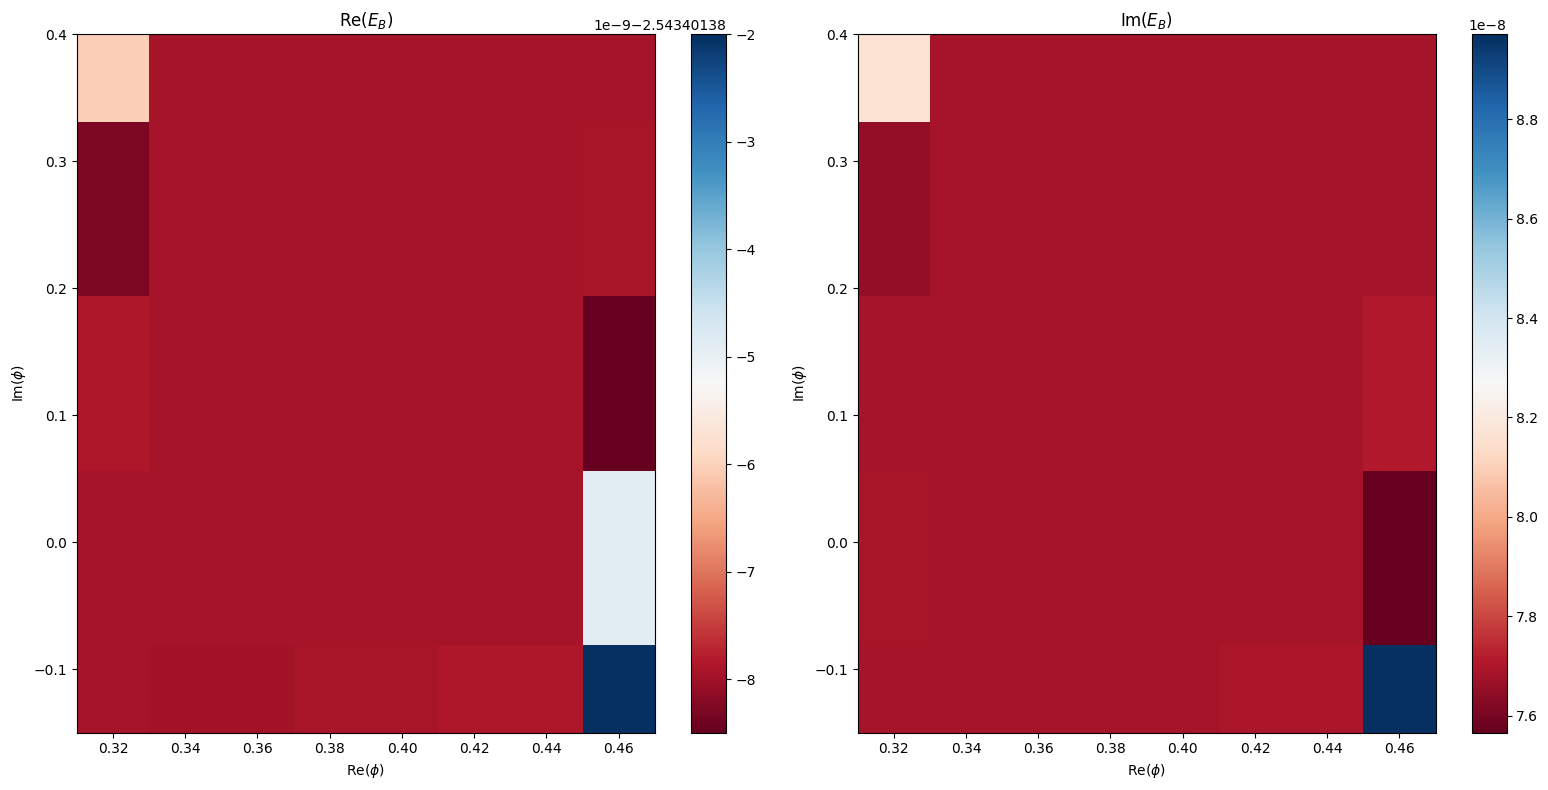

In [10]:
# energy plot
figsize = (16,8)

plot_data_over_phi_grid(phis_real, phis_imag, energies, title=r'$E_R$', figsize=figsize)
plt.show()

# rr plot
plot_data_over_phi_grid(phis_real, phis_imag, rrs, title=r'$(r^2)$', figsize=figsize)
plt.show()

# telem plot
plot_data_over_phi_grid(phis_real, phis_imag, telems, title=r'$T_{E1}$', figsize=figsize)
plt.show()

# real bound state energy plot
plot_data_over_phi_grid(phis_real, phis_imag, benergies, title=r'$E_B$', figsize=figsize)
plt.show()

### Automate search for best $(L, $mesh width$,\phi)$

In [11]:
# automate search for best L, n (mesh width) (scans over observables looking for plateaus).
# - run search_mesh_width over a suitable range of mesh widths for a few values of L (this gets expensive if L is large and mesh width is too small)
# - pick the best mesh width from the batch
# - run search_L at the winning mesh width for a suitable range of L
# - pick the winning L. This gives L_best, n_best
L_best, n_best = 50.0, 256
pres_system = DVR(n_best, L_best, phi_guess, potential=gauss_barrier, l=1)
sbound_system = DVR(n_best, L_best, phi_guess, potential=gauss_barrier, l=0)

# using the new DVR guess, find the best range for training Re(phi)
# - run search_optimal_phirange to find the best range for Re(phi)
phi_best = 0.35
phi_real_range = [0.31, 0.47]

# using the winning real phis, scan over the imaginary component to find the best range for training Im(phi)
# - this isn't implemented in sweep_utils.py yet.
phi_imag_range = [-0.15, 0.4]

### Get training data over $\Re(\phi)$ and use that to compute references

In [12]:
num_real_training_points = 25

phi_real_train = np.linspace(phi_real_range[0], phi_real_range[1], num_real_training_points)
training_results = linesweep_phi(
    pres_system,
    res_guess,
    phi_real_train,
    observables,
    sbound_system,
    bound_guess
)
print_training_data(training_results)
real_res = get_reference(training_results["energies"], tol=1e-3) 
real_rr = get_reference(training_results["rrs"], tol=1e-2)
real_telem = get_reference(training_results["telems"], tol=1e-3)
real_bound = get_reference(training_results["bound_energies"], tol=1e-3)

Training energies: (0.27712 +- 0.00010) + i(-0.09319 +- 0.00018)
Training rrs: (1.34664 +- 0.00107) + i(1.49686 +- 0.00197)
Training telems: (0.75115 +- 0.00034) + i(-0.19175 +- 0.00019)
Training bound_energies: (-2.54340 +- 0.00000) + i(0.00000 +- 0.00000)


### Train EC on complex $\theta$.

In [13]:
# get complex training set
nimag = 5
nreal = 5
phir = np.linspace(phi_real_range[0], phi_real_range[1], nreal)
phii = np.linspace(phi_imag_range[0], phi_imag_range[1], nimag)

phi_complex_train = []
for pr in phir:
    for pii in phii:
        phi_complex_train.append(pr + 1j*pii)
phi_complex_train = np.asarray(phi_complex_train, dtype=np.complex128)

# full training set
phi_train = np.concatenate((phi_real_train, phi_complex_train))

In [14]:
# train on complex rotation angles
pres_system.reset_rotation_angle(phi_best)
sbound_system.reset_rotation_angle(phi_best) 
ec_system = ECSystem(pres_system, real_res)

ec_system.train(phi_train)
ec_system.construct_basis()

print(
    f"EC trained on {num_real_training_points+(nimag*nreal)} total training points.\n"
    f"{num_real_training_points} of the training points are pure real in [{phi_real_range[0]:.5f}, {phi_real_range[1]:.5f}].\n"
    f"{nimag*nreal} training points are complex: real resolution (Re(phi range), num real) = ([{phi_real_range[0]:.5f}, {phi_real_range[1]:.5f}], {nreal})\n"
    f"imaginary resolution (Im(phi range), num imag) = ([{phi_imag_range[0]:.5f}, {phi_imag_range[1]:.5f}], {nimag})\n"
)

EC trained on 50 total training points.
25 of the training points are pure real in [0.31000, 0.47000].
25 training points are complex: real resolution (Re(phi range), num real) = ([0.31000, 0.47000], 5)
imaginary resolution (Im(phi range), num imag) = ([-0.15000, 0.40000], 5)



### Predictions

#### Interpolation to $\phi$ in the good region

In [15]:
phi_predict = phi_best # np.median(np.real(phi_train)) + 1j*np.median(np.imag(phi_train))

observables = {"energy": predict_energy, "rr": predict_rr, "telem": predict_telem}
references = {"energy": real_res, "rr" : real_rr, "telem": real_telem, "bound_energy": real_bound}
results = quick_predict(
    ec_system,
    phi_predict,
    observables,
    pres_system,
    real_res,
    sbound_system,
    real_bound
)
print(f"-----------------------------------\n Results (Interpolation to phi={phi_predict.real:.3f}+i{phi_predict.imag:.3f}) \n ----------------------------------")
print_quick_predict(results)
print("-----------------------------------\n Residuals \n ------------------------")
print_quick_predict(quick_residuals(references, results))
print("-----------------------------------\n Relative Residuals \n ------------------------")
results.pop("bound_energy")
print_quick_predict(quick_residuals(references, results, relative=True))

-----------------------------------
 Results (Interpolation to phi=0.350+i0.000) 
 ----------------------------------
bound_energy:-2.54340 + i0.00000
energy:0.27704 + i-0.09304
rr:1.34581 + i1.49589
telem:0.75142 + i-0.19168
-----------------------------------
 Residuals 
 ------------------------
bound_energy:0.00000 + i0.00000
energy:0.00008 + i0.00015
rr:0.00083 + i0.00080
telem:0.00027 + i0.00007
-----------------------------------
 Relative Residuals 
 ------------------------
energy:0.00030 + i-0.00162
rr:0.00062 + i0.00054
telem:0.00036 + i-0.00036


#### Extrapolation to $\phi=0.0$

In [16]:
phi_predict = 0.0

results = quick_predict(
    ec_system,
    phi_predict,
    observables,
    pres_system,
    real_res,
    sbound_system,
    real_bound
)
print(f"-----------------------------------\n Results (Extrapolation to phi={phi_predict:.4f}) \n ----------------------------------")
print_quick_predict(results)
print("-----------------------------------\n Residuals \n ------------------------")
print_quick_predict(quick_residuals(references, results))
print("-----------------------------------\n Relative Residuals \n ------------------------")
results.pop("bound_energy")
print_quick_predict(quick_residuals(references, results, relative=True))

-----------------------------------
 Results (Extrapolation to phi=0.0000) 
 ----------------------------------
bound_energy:-2.54340 + i0.00000
energy:0.26620 + i0.02334
rr:3.47987 + i0.41932
telem:0.53032 + i-0.08871
-----------------------------------
 Residuals 
 ------------------------
bound_energy:0.00000 + i0.00000
energy:0.01092 + i0.11653
rr:2.13323 + i1.07737
telem:0.22083 + i0.10303
-----------------------------------
 Relative Residuals 
 ------------------------
energy:0.03942 + i-1.25048
rr:1.58412 + i0.71983
telem:0.29399 + i-0.53734


#### Compare to performance when trained on just real values

In [17]:
# train on purely real rotation angles
pres_system.reset_rotation_angle(phi_best)
sbound_system.reset_rotation_angle(phi_best)
ec_system = ECSystem(pres_system, real_res)

# get training data
numt = num_real_training_points + nimag*nreal # train on the total number of training points from before
phi_train = np.linspace(phi_real_range[0], phi_real_range[1], numt, dtype=np.complex128)

ec_system.train(phi_train)
ec_system.construct_basis()

In [18]:
phi_predict = phi_best # np.median(np.real(phi_train)) + 1j*np.median(np.imag(phi_train))

results = quick_predict(
    ec_system,
    phi_predict,
    observables,
    pres_system,
    real_res,
    sbound_system,
    real_bound
)
print(f"-----------------------------------\n Results (Interpolation to phi={phi_predict.real:.3f}+i{phi_predict.imag:.3f}) \n ----------------------------------")
print_quick_predict(results)
print("-----------------------------------\n Residuals \n ------------------------")
print_quick_predict(quick_residuals(references, results))
print("-----------------------------------\n Relative Residuals \n ------------------------")
results.pop("bound_energy")
print_quick_predict(quick_residuals(references, results, relative=True))

-----------------------------------
 Results (Interpolation to phi=0.350+i0.000) 
 ----------------------------------
bound_energy:-2.54340 + i0.00000
energy:0.27704 + i-0.09304
rr:1.34578 + i1.49591
telem:0.75142 + i-0.19168
-----------------------------------
 Residuals 
 ------------------------
bound_energy:0.00000 + i0.00000
energy:0.00008 + i0.00015
rr:0.00086 + i0.00078
telem:0.00027 + i0.00007
-----------------------------------
 Relative Residuals 
 ------------------------
energy:0.00030 + i-0.00162
rr:0.00064 + i0.00052
telem:0.00036 + i-0.00034


In [19]:
phi_predict = 0.0

results = quick_predict(
    ec_system,
    phi_predict,
    observables,
    pres_system,
    real_res,
    sbound_system,
    real_bound
)
print(f"-----------------------------------\n Results (Extrapolation to phi={phi_predict:.4f}) \n ----------------------------------")
print_quick_predict(results)
print("-----------------------------------\n Residuals \n ------------------------")
print_quick_predict(quick_residuals(references, results))
print("-----------------------------------\n Relative Residuals \n ------------------------")
results.pop("bound_energy")
print_quick_predict(quick_residuals(references, results, relative=True))

-----------------------------------
 Results (Extrapolation to phi=0.0000) 
 ----------------------------------
bound_energy:-2.54340 + i0.00000
energy:0.23638 + i-0.02408
rr:2.12637 + i0.88913
telem:0.72986 + i-0.07490
-----------------------------------
 Residuals 
 ------------------------
bound_energy:0.00000 + i0.00000
energy:0.04075 + i0.06910
rr:0.77973 + i0.60757
telem:0.02129 + i0.11685
-----------------------------------
 Relative Residuals 
 ------------------------
energy:0.14704 + i-0.74156
rr:0.57902 + i0.40594
telem:0.02835 + i-0.60940
